In [1]:
print("Hello, Task 1 is working!")

Hello, Task 1 is working!


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
print("Libraries loaded successfully")

Libraries loaded successfully


In [37]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [38]:
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [39]:
df = df.drop(columns=["Unnamed: 0"])

In [40]:
df["stock"].value_counts()

stock
MRK      3333
MS       3238
NVDA     3146
MU       3142
QQQ      3106
         ... 
XXV         1
YMLI        1
YYY         1
ZIONW       1
ZMLP        1
Name: count, Length: 6204, dtype: int64

In [41]:
df["publisher"].value_counts().head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

In [42]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [43]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

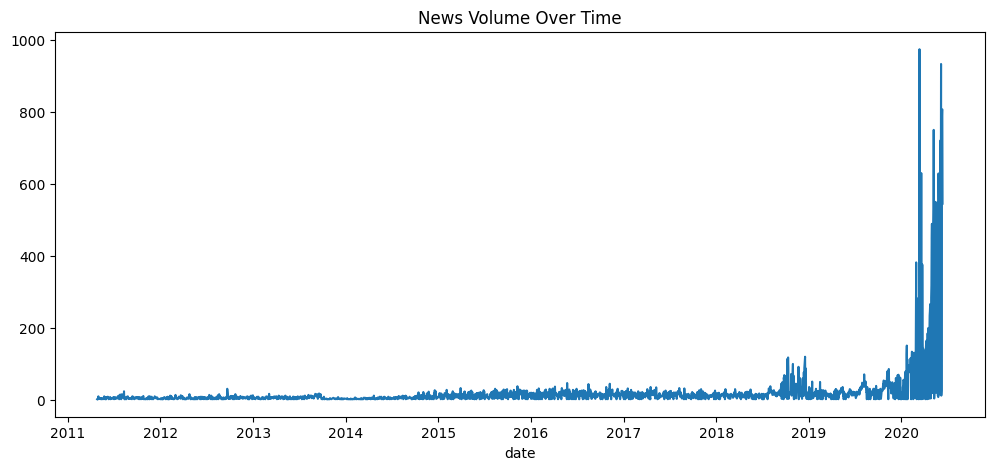

In [32]:
df["date"].dt.date.value_counts().sort_index().plot(figsize=(12,5))
plt.title("News Volume Over Time")
plt.show()

In [33]:
headlines = df["headline"].astype(str)

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english", max_features=20)
X = vectorizer.fit_transform(headlines)

In [14]:
import pandas as pd

words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

word_freq = pd.DataFrame({"word": words, "count": counts})
word_freq = word_freq.sort_values(by="count", ascending=False)

word_freq

,word,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


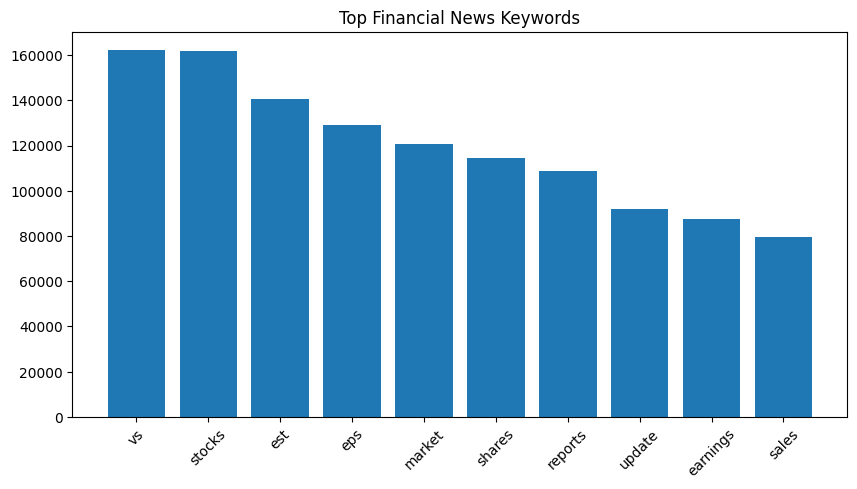

In [15]:
import matplotlib.pyplot as plt

top_words = word_freq.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_words["word"], top_words["count"])
plt.xticks(rotation=45)
plt.title("Top Financial News Keywords")
plt.show()

In [16]:
df["publisher"].value_counts().head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

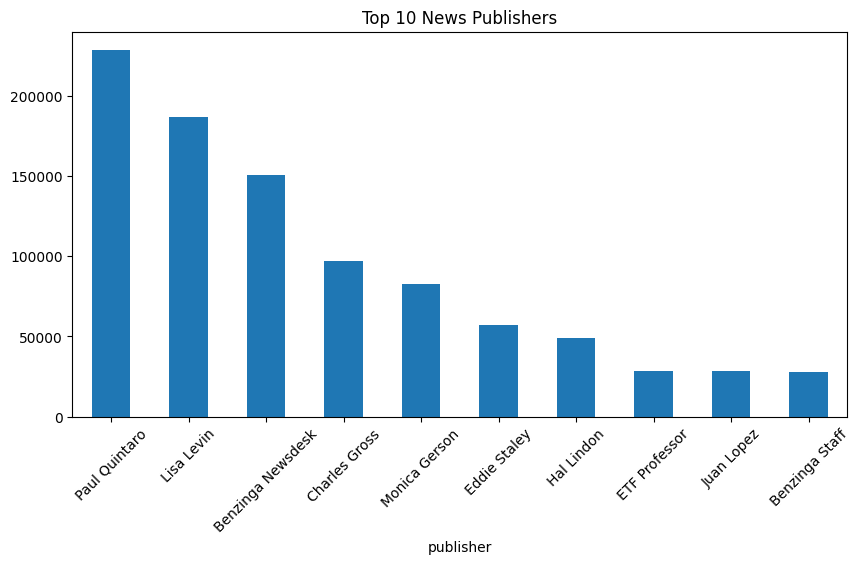

In [17]:
import matplotlib.pyplot as plt

top_publishers = df["publisher"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_publishers.plot(kind="bar")
plt.title("Top 10 News Publishers")
plt.xticks(rotation=45)
plt.show()

In [18]:
df["publisher_domain"] = df["publisher"].apply(lambda x: x.split("@")[-1] if "@" in str(x) else x)

In [19]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [20]:
df["hour"] = df["date"].dt.hour
df["day_name"] = df["date"].dt.day_name()

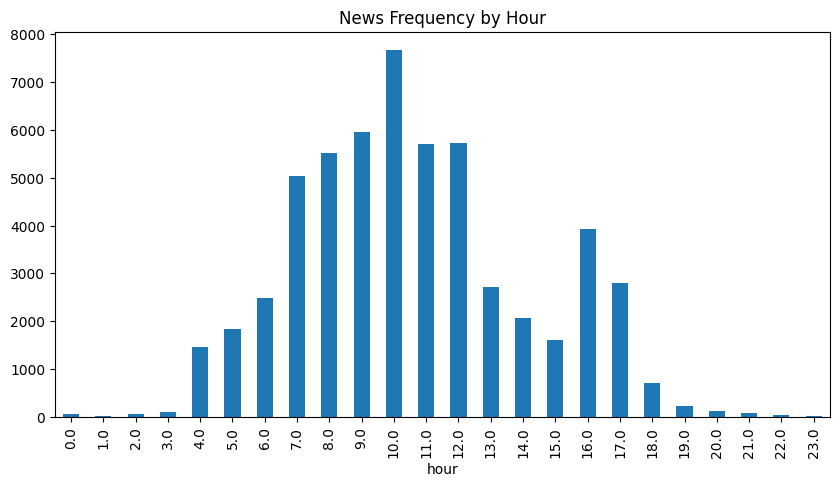

In [21]:
import matplotlib.pyplot as plt

df["hour"].value_counts().sort_index().plot(kind="bar", figsize=(10,5))
plt.title("News Frequency by Hour")
plt.show()

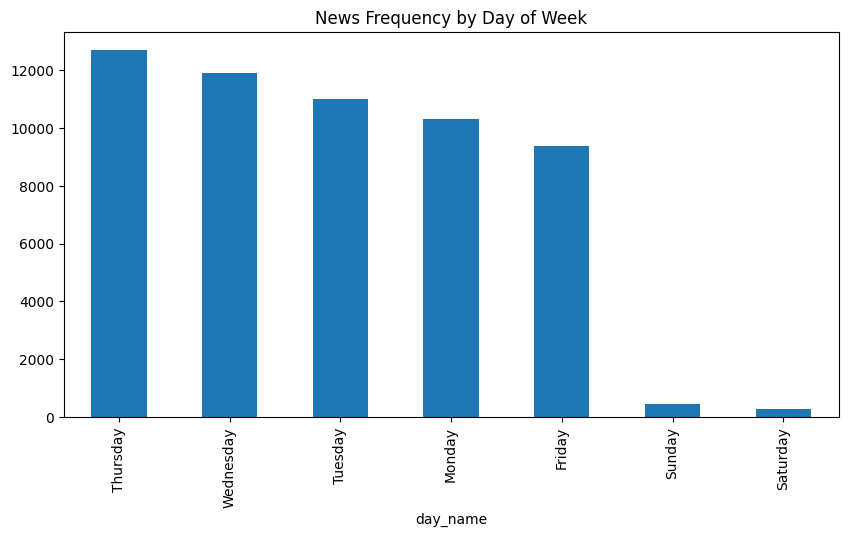

In [22]:
df["day_name"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("News Frequency by Day of Week")
plt.show()